In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Repo root (adjust if your notebook is launched from a different cwd)
REPO_ROOT = Path("/home/pirie03/projects/aip-medilab/pirie03/ProstateMicroSeg")

DATA_ROOT = REPO_ROOT / "dataset" / "processed" / "Dataset120_MicroUSProstate"
IMAGES_TR = DATA_ROOT / "imagesTr"
LABELS_TR = DATA_ROOT / "labelsTr"

print("IMAGES_TR:", IMAGES_TR)
print("LABELS_TR:", LABELS_TR)

IMAGES_TR: /home/pirie03/projects/aip-medilab/pirie03/ProstateMicroSeg/dataset/processed/Dataset120_MicroUSProstate/imagesTr
LABELS_TR: /home/pirie03/projects/aip-medilab/pirie03/ProstateMicroSeg/dataset/processed/Dataset120_MicroUSProstate/labelsTr


In [3]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[1]))

from src.data.extractors.patch_centered_fg import extract as extract_centered
from src.data.extractors.patch_random_fg import extract as extract_random

print("Loaded extractors:", extract_centered.__name__, extract_random.__name__)

Loaded extractors: extract extract


In [4]:
case_id = "microUS_01"

img_path = IMAGES_TR / f"{case_id}.npy"
lbl_path = LABELS_TR / f"{case_id}.npy"

print("img_path:", img_path)
print("lbl_path:", lbl_path)

img_np = np.load(img_path).astype(np.float32)
lbl_np = np.load(lbl_path).astype(np.float32)

print("img shape:", img_np.shape, "dtype:", img_np.dtype)
print("lbl shape:", lbl_np.shape, "dtype:", lbl_np.dtype)
print("label values:", np.unique(lbl_np)[:10])

assert img_np.ndim == 3
assert lbl_np.ndim == 3
assert img_np.shape == lbl_np.shape

img_path: /home/pirie03/projects/aip-medilab/pirie03/ProstateMicroSeg/dataset/processed/Dataset120_MicroUSProstate/imagesTr/microUS_01.npy
lbl_path: /home/pirie03/projects/aip-medilab/pirie03/ProstateMicroSeg/dataset/processed/Dataset120_MicroUSProstate/labelsTr/microUS_01.npy
img shape: (45, 962, 1372) dtype: float32
lbl shape: (45, 962, 1372) dtype: float32
label values: [0. 1.]


In [5]:
def fg_mask(lbl_patch: np.ndarray, fg_threshold: float) -> np.ndarray:
    return lbl_patch > fg_threshold

def fg_fraction(lbl_patch: np.ndarray, fg_threshold: float) -> float:
    return float(fg_mask(lbl_patch, fg_threshold).mean())

def fg_centroid_zyx(lbl_patch: np.ndarray, fg_threshold: float):
    m = fg_mask(lbl_patch, fg_threshold)
    if not m.any():
        return None
    coords = np.argwhere(m)  # (z,y,x)
    c = coords.mean(axis=0)
    return (float(c[0]), float(c[1]), float(c[2]))

def centroid_distance_to_patch_center(lbl_patch: np.ndarray, fg_threshold: float):
    c = fg_centroid_zyx(lbl_patch, fg_threshold)
    if c is None:
        return None, None

    Z, Y, X = lbl_patch.shape
    center = np.array([(Z - 1) / 2.0, (Y - 1) / 2.0, (X - 1) / 2.0], dtype=np.float32)
    c_arr = np.array(c, dtype=np.float32)

    dist = float(np.linalg.norm(c_arr - center))
    dist_norm = float(dist / (np.linalg.norm(center) + 1e-8))
    return dist, dist_norm

def pick_random_z_indices(Z: int, rng: np.random.Generator, n_slices: int = 3) -> list[int]:
    if Z <= 0:
        raise ValueError("Z must be > 0")

    n = min(int(n_slices), Z)  # if Z < 3, just take as many as possible
    zs = rng.choice(Z, size=n, replace=False)
    zs = np.sort(zs).astype(int).tolist()
    return zs

def _norm01(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

def plot_patch_pair_one_z(
    img_c: np.ndarray, lbl_c: np.ndarray,
    img_r: np.ndarray, lbl_r: np.ndarray,
    *,
    z: int,
    fg_threshold: float,
    title: str | None = None,
):
    Z = img_c.shape[0]
    z = int(np.clip(z, 0, Z - 1))

    ic, lc = img_c[z], lbl_c[z]
    ir, lr = img_r[z], lbl_r[z]

    mc = (lc > fg_threshold)
    mr = (lr > fg_threshold)

    ic01 = _norm01(ic)
    ir01 = _norm01(ir)

    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 12))
    if title is not None:
        fig.suptitle(title)

    # Row 1: image
    axes[0, 0].imshow(ic, cmap="gray")
    axes[0, 0].set_title(f"Centered img (z={z})")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(ir, cmap="gray")
    axes[0, 1].set_title(f"Random img (z={z})")
    axes[0, 1].axis("off")

    # Row 2: label
    axes[1, 0].imshow(lc, cmap="gray")
    axes[1, 0].set_title("Centered label")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(lr, cmap="gray")
    axes[1, 1].set_title("Random label")
    axes[1, 1].axis("off")

    # Row 3: overlay
    axes[2, 0].imshow(ic01, cmap="gray")
    axes[2, 0].imshow(mc, alpha=0.35)
    axes[2, 0].set_title("Centered overlay")
    axes[2, 0].axis("off")

    axes[2, 1].imshow(ir01, cmap="gray")
    axes[2, 1].imshow(mr, alpha=0.35)
    axes[2, 1].set_title("Random overlay")
    axes[2, 1].axis("off")

    plt.tight_layout()
    plt.show()

In [6]:
def visualize_k_with_random_zs(
    img_c: np.ndarray, lbl_c: np.ndarray,
    img_r: np.ndarray, lbl_r: np.ndarray,
    *,
    seed_for_z: int,
    fg_threshold: float,
    n_slices: int = 3,
    title_prefix: str = "",
):
    Z = img_c.shape[0]
    rng_z = np.random.default_rng(seed_for_z)
    zs = pick_random_z_indices(Z, rng=rng_z, n_slices=n_slices)

    for z in zs:
        plot_patch_pair_one_z(
            img_c, lbl_c, img_r, lbl_r,
            z=z,
            fg_threshold=fg_threshold,
            title=f"{title_prefix} z={z}"
        )

In [ ]:
target_zyx = (14, 500, 600) 
fg_threshold = 0.5
deterministic = False
force_fg = True

# For centered extractor, set jitter if you want to see its effect
center_jitter_zyx = (2, 32, 32)

N = 5
seed_base = 12345

k=0 seed=12345 center_zyx(c)=(31, 812, 505) center_zyx(r)=(31, 812, 505) force_fg_used(c)=True force_fg_used(r)=True


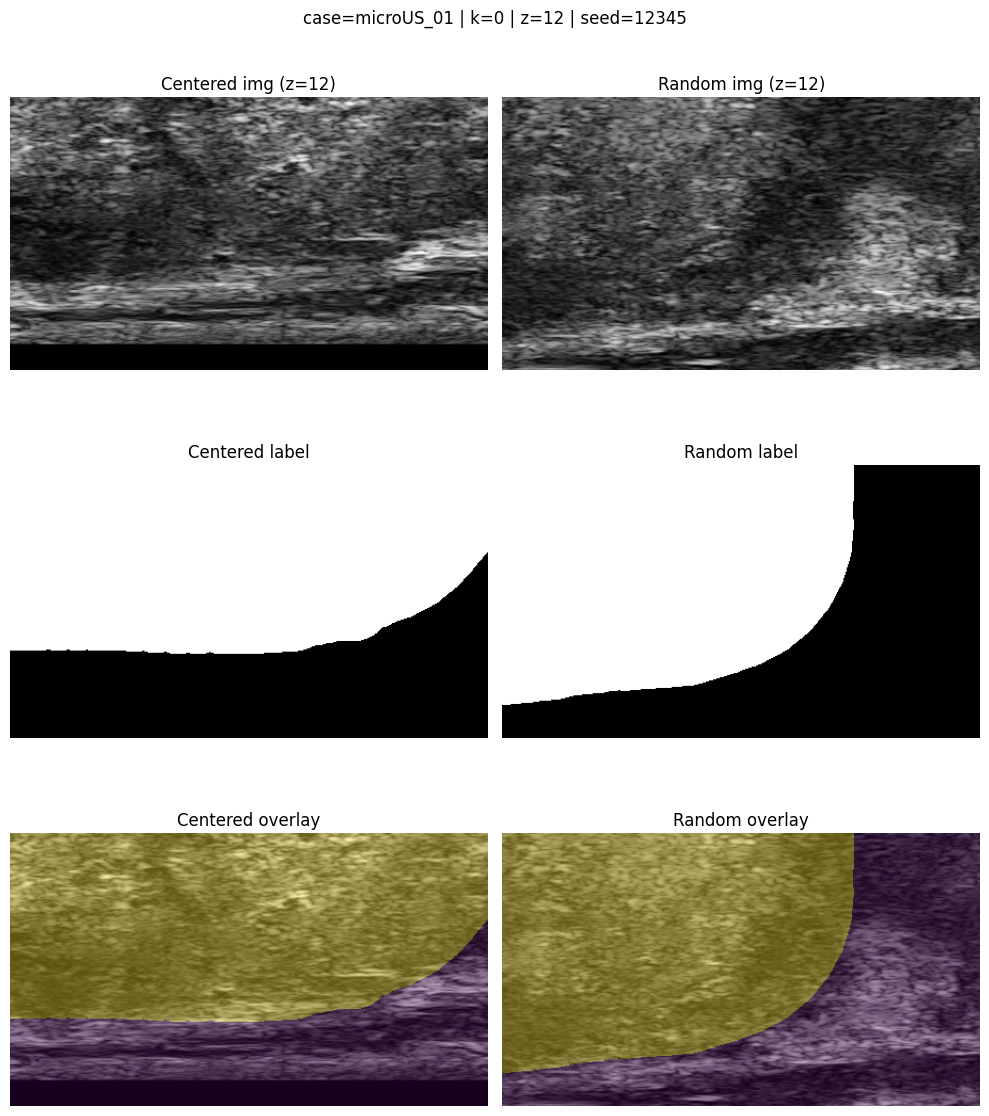

k=1 seed=12346 center_zyx(c)=(28, 580, 767) center_zyx(r)=(28, 580, 767) force_fg_used(c)=True force_fg_used(r)=True


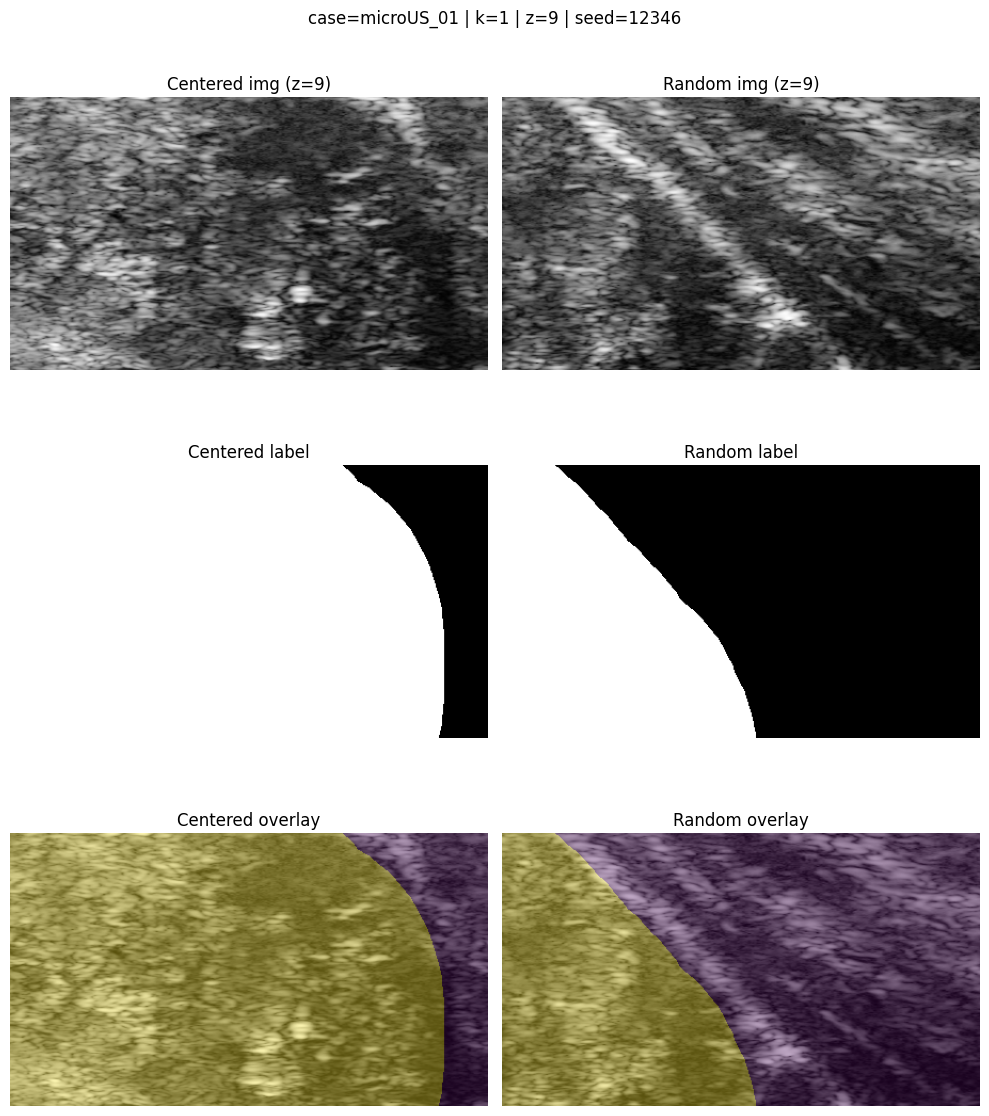

k=2 seed=12347 center_zyx(c)=(29, 722, 621) center_zyx(r)=(29, 722, 621) force_fg_used(c)=True force_fg_used(r)=True


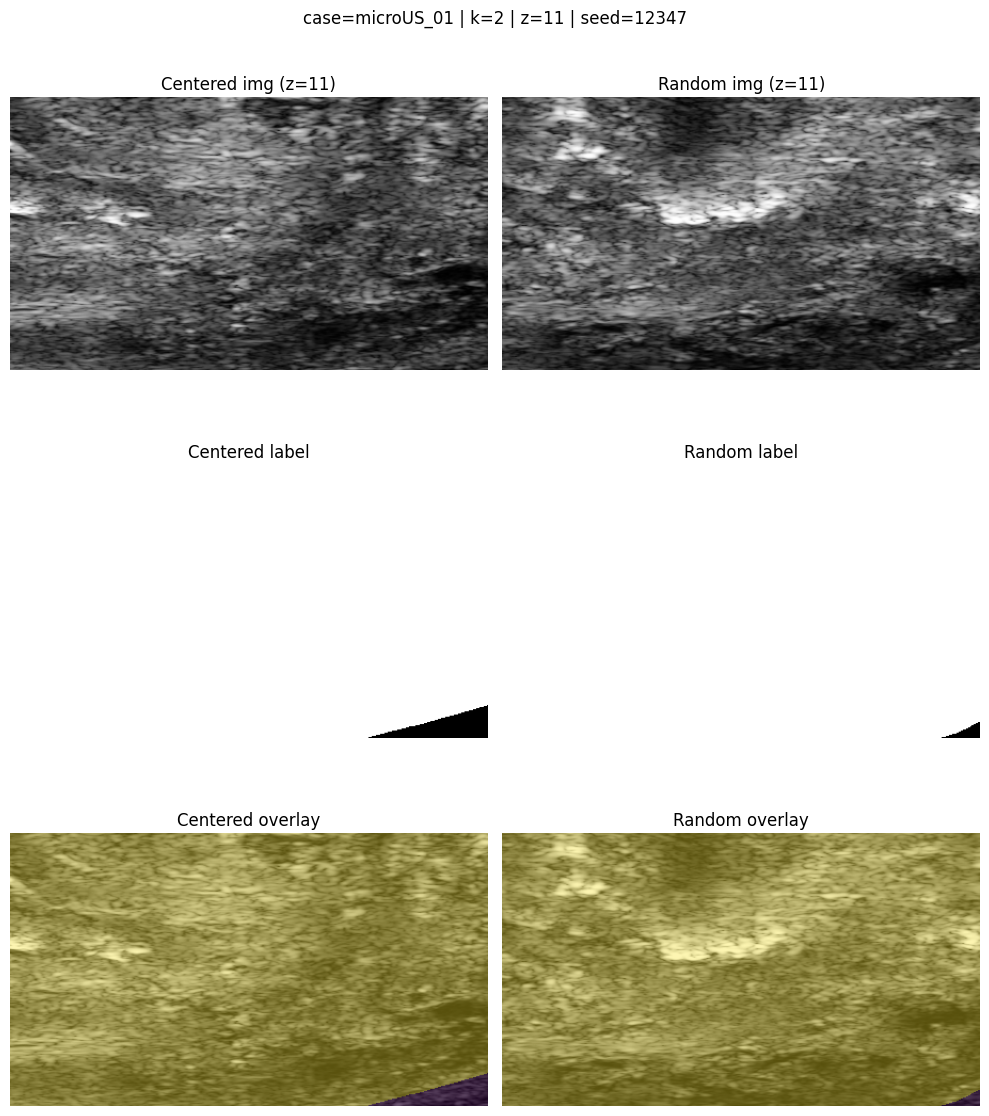

k=3 seed=12348 center_zyx(c)=(27, 484, 213) center_zyx(r)=(27, 484, 213) force_fg_used(c)=True force_fg_used(r)=True


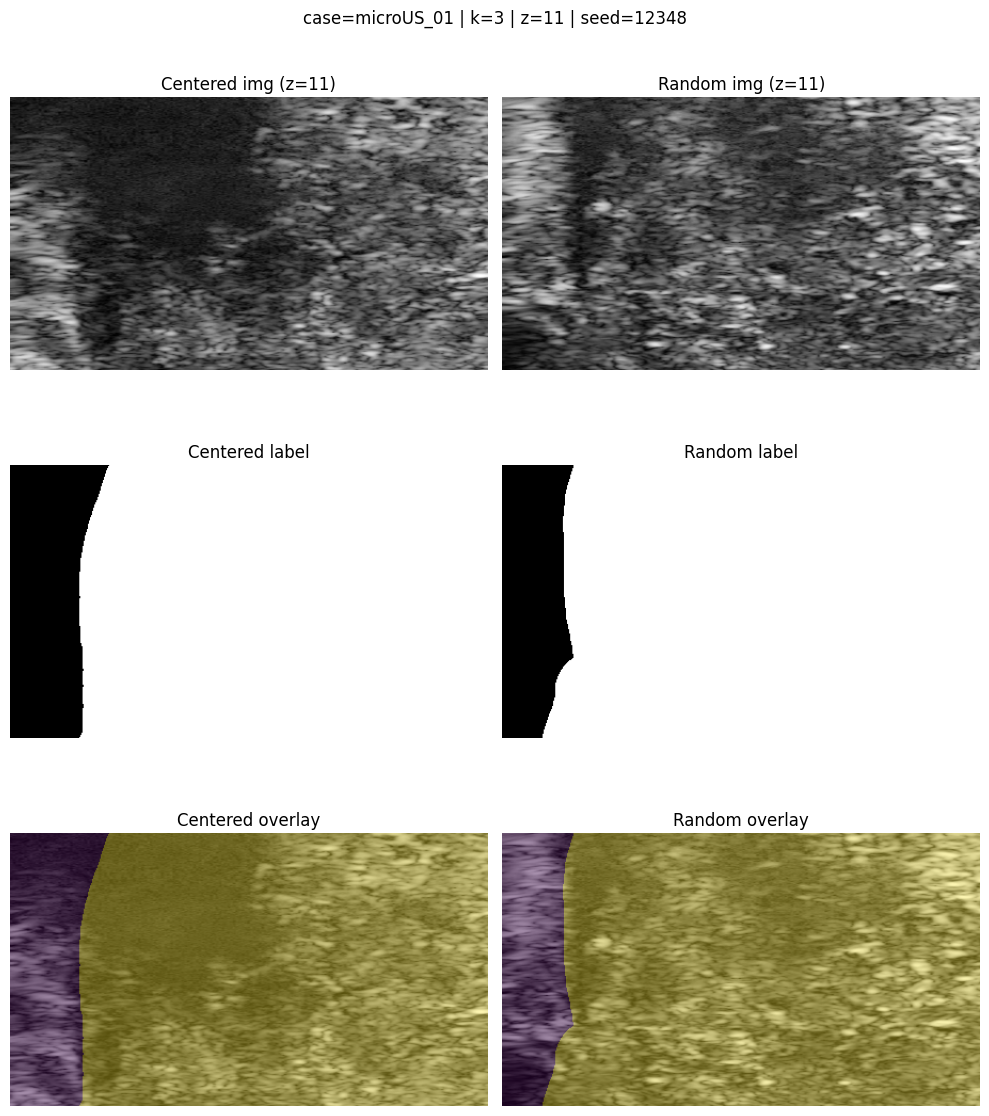

k=4 seed=12349 center_zyx(c)=(35, 490, 769) center_zyx(r)=(35, 490, 769) force_fg_used(c)=True force_fg_used(r)=True


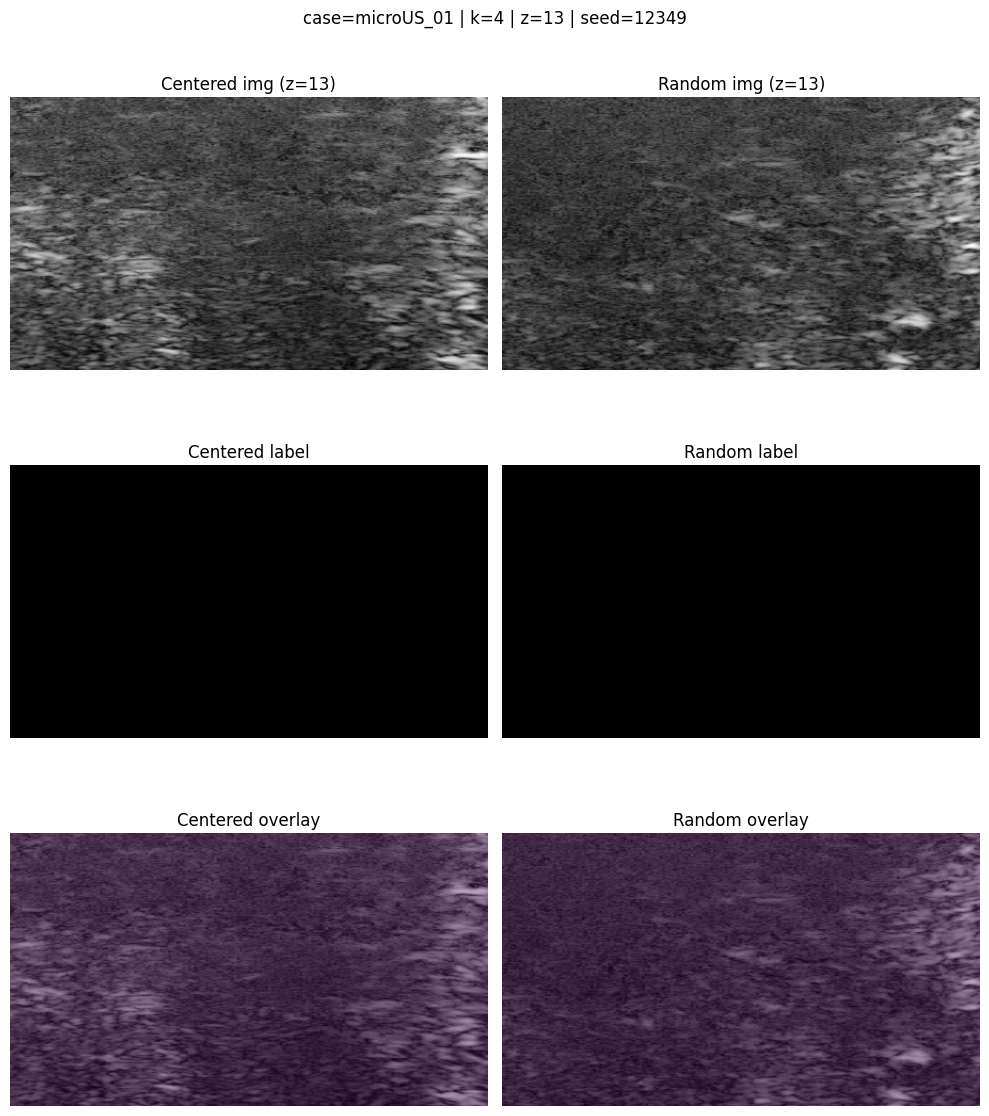


Summary over N = 5
FG fraction (centered): mean 0.7810731530189514 std 0.19401298463344574
FG fraction (random):   mean 0.6588612794876099 std 0.3276914954185486
Dist norm (centered):   mean 0.13416698575019836 std 0.11488979309797287
Dist norm (random):     mean 0.21754451096057892 std 0.22612328827381134
force_fg_used=False counts: centered 0 random 0


In [9]:
# Which k's to visualize (all of them for N=5)
show_k = set(range(N))

results = []

for k in range(N):
    seed = seed_base + k

    # Paired RNGs: same seed so the FG voxel selection matches
    rng_c = np.random.default_rng(seed)
    rng_r = np.random.default_rng(seed)

    # Extract patches
    img_c, lbl_c, meta_c = extract_centered(
        img_np,
        lbl_np,
        target_zyx=target_zyx,
        rng=rng_c,
        deterministic=deterministic,
        force_fg=force_fg,
        fg_threshold=fg_threshold,
        center_jitter_zyx=center_jitter_zyx,
    )

    img_r, lbl_r, meta_r = extract_random(
        img_np,
        lbl_np,
        target_zyx=target_zyx,
        rng=rng_r,
        deterministic=deterministic,
        force_fg=force_fg,
        fg_threshold=fg_threshold,
    )

    # Metrics you wanted
    frac_c = fg_fraction(lbl_c, fg_threshold)
    frac_r = fg_fraction(lbl_r, fg_threshold)

    dist_c, distn_c = centroid_distance_to_patch_center(lbl_c, fg_threshold)
    dist_r, distn_r = centroid_distance_to_patch_center(lbl_r, fg_threshold)

    results.append({
        "k": k,
        "seed": seed,
        "center_zyx_centered": meta_c.get("center_zyx"),
        "center_zyx_random": meta_r.get("center_zyx"),
        "force_fg_used_centered": meta_c.get("force_fg_used"),
        "force_fg_used_random": meta_r.get("force_fg_used"),
        "fg_frac_centered": frac_c,
        "fg_frac_random": frac_r,
        "dist_norm_centered": distn_c,
        "dist_norm_random": distn_r,
    })

    # Quick sanity print
    print(
        f"k={k} seed={seed} "
        f"center_zyx(c)={meta_c.get('center_zyx')} center_zyx(r)={meta_r.get('center_zyx')} "
        f"force_fg_used(c)={meta_c.get('force_fg_used')} force_fg_used(r)={meta_r.get('force_fg_used')}"
    )

    # Visualize ONE random z slice for this k (same z used for both patches)
    if k in show_k:
        Z = img_c.shape[0]
        rng_z = np.random.default_rng(seed + 10_000)  # separate stream so it doesn't affect patch sampling
        z = int(rng_z.integers(0, Z))  # one random slice index

        plot_patch_pair_one_z(
            img_c, lbl_c,
            img_r, lbl_r,
            z=z,
            fg_threshold=fg_threshold,
            title=f"case={case_id} | k={k} | z={z} | seed={seed}"
        )

# Summary across N
fg_c = np.array([r["fg_frac_centered"] for r in results], dtype=np.float32)
fg_r = np.array([r["fg_frac_random"] for r in results], dtype=np.float32)

d_c = np.array([r["dist_norm_centered"] for r in results if r["dist_norm_centered"] is not None], dtype=np.float32)
d_r = np.array([r["dist_norm_random"] for r in results if r["dist_norm_random"] is not None], dtype=np.float32)

miss_c = sum(1 for r in results if r["force_fg_used_centered"] is False)
miss_r = sum(1 for r in results if r["force_fg_used_random"] is False)

print("\nSummary over N =", N)
print("FG fraction (centered): mean", float(fg_c.mean()), "std", float(fg_c.std()))
print("FG fraction (random):   mean", float(fg_r.mean()), "std", float(fg_r.std()))
print("Dist norm (centered):   mean", float(d_c.mean()), "std", float(d_c.std()))
print("Dist norm (random):     mean", float(d_r.mean()), "std", float(d_r.std()))
print("force_fg_used=False counts:", "centered", miss_c, "random", miss_r)